In [1]:
# ============================================================================
# CELL 1: INSTALL AND IMPORT PACKAGES
# ============================================================================
print("Installing required packages...")
!pip install dash plotly pandas -q

import os
os.environ["DASH_JUPYTER_MODE"] = "external"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html
import warnings
warnings.filterwarnings('ignore')

print("✓ All packages installed and imported!")

Installing required packages...
zsh:1: command not found: pip


✓ All packages installed and imported!


/Users/dennisisong/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
print("Loading data...")

from pathlib import Path

csv_candidates = [Path('simulated_data.csv'), Path('simulated_data (1).csv')]
for csv_path in csv_candidates:
    if csv_path.exists():
        df_original = pd.read_csv(csv_path)
        break
else:
    raise FileNotFoundError("Could not find simulated_data.csv or simulated_data (1).csv")

print(f"✓ Data loaded: {df_original.shape[0]:,} rows × {df_original.shape[1]} columns")


Loading data...
✓ Data loaded: 40,000 rows × 47 columns


In [3]:
# ============================================================================
# CELL 3: ENHANCE DATASET
# ============================================================================
print("="*80)
print("ENHANCING DATASET")
print("="*80)

df_enhanced = df_original.copy()
df_enhanced['Worked Date'] = pd.to_datetime(df_enhanced['Worked Date'])

# Budget & Forecast
project_actuals = df_enhanced.groupby('Project Name').agg({
    'Billable Hours': 'sum',
    'Revenue': 'sum',
    'Gross Margin': 'sum'
}).reset_index()

np.random.seed(42)
project_budgets = project_actuals.copy()
project_budgets['Project Budget Hours'] = project_actuals['Billable Hours'] * np.random.uniform(0.85, 1.15, len(project_actuals))
project_budgets['Project Budget Revenue'] = project_actuals['Revenue'] * np.random.uniform(0.90, 1.10, len(project_actuals))
project_budgets['Expected Gross Margin'] = project_actuals['Gross Margin'] * np.random.uniform(0.85, 1.15, len(project_actuals))

df_enhanced = df_enhanced.merge(
    project_budgets[['Project Name', 'Project Budget Hours', 'Project Budget Revenue', 'Expected Gross Margin']],
    on='Project Name', how='left'
)

# Client Relationship
client_first_date = df_enhanced.groupby('Client Name')['Worked Date'].min().reset_index()
reference_date = df_enhanced['Worked Date'].max()
client_first_date['Client Tenure Months'] = ((reference_date - client_first_date['Worked Date']).dt.days / 30).astype(int)
df_enhanced = df_enhanced.merge(client_first_date[['Client Name', 'Client Tenure Months']], on='Client Name', how='left')

np.random.seed(43)
client_satisfaction = pd.DataFrame({
    'Client Name': df_enhanced['Client Name'].unique(),
    'Client Satisfaction Score': np.random.triangular(6, 8, 10, len(df_enhanced['Client Name'].unique()))
})
df_enhanced = df_enhanced.merge(client_satisfaction, on='Client Name', how='left')

# Resource & Capability
role_experience_map = {
    'Partner': (15, 25),
    'Principal Consultant': (10, 18),
    'Senior Consultant': (6, 12),
    'Consultant': (3, 8),
    'Associate Consultant': (1, 4),
    'Analyst': (0, 3)
}

df_enhanced['Consultant Experience Years'] = df_enhanced['Consultant Role'].apply(
    lambda x: np.random.randint(*role_experience_map.get(x, (3, 8)))
)

# Save enhanced dataset
df_enhanced.to_csv('simulated_data_enhanced.csv', index=False)
print(f"✓ Enhanced dataset: {df_enhanced.shape[0]:,} rows × {df_enhanced.shape[1]} columns")


ENHANCING DATASET


✓ Enhanced dataset: 40,000 rows × 52 columns


In [4]:
# ============================================================================
# CELL 4: COUNT COLUMNS ADDED DURING ENHANCEMENT
# ============================================================================

print("="*80)
print("COLUMN COUNT ANALYSIS")
print("="*80)

# Original columns
original_columns = df_original.shape[1]
print(f"\n📊 Original Dataset Columns: {original_columns}")

# Enhanced columns
enhanced_columns = df_enhanced.shape[1]
print(f"📊 Enhanced Dataset Columns: {enhanced_columns}")

# Columns added
columns_added = enhanced_columns - original_columns
print(f"\n✅ New Columns Added: {columns_added}")

print("\n" + "-"*80)
print("ORIGINAL COLUMNS:")
print("-"*80)
for i, col in enumerate(df_original.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "-"*80)
print("NEW COLUMNS ADDED:")
print("-"*80)

new_columns = [col for col in df_enhanced.columns if col not in df_original.columns]
for i, col in enumerate(new_columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "="*80)
print(f"SUMMARY: {columns_added} new columns were added during enhancement")
print("="*80)

COLUMN COUNT ANALYSIS

📊 Original Dataset Columns: 47
📊 Enhanced Dataset Columns: 52

✅ New Columns Added: 5

--------------------------------------------------------------------------------
ORIGINAL COLUMNS:
--------------------------------------------------------------------------------
 1. Index
 2. Client Name
 3. Client Industry
 4. Project Name
 5. Project Type
 6. Project Status
 7. Contract Type
 8. Worked Date
 9. Consultant Name
10. Consultant Role
11. Practice Area
12. Task Category
13. Client Region
14. Engagement Manager
15. Billable Flag
16. Billable Hours
17. Hourly Billing Rate
18. Internal Cost Rate
19. Revenue
20. Total Cost
21. Gross Margin
22. Utilization Flag
23. Project Budget Hours
24. Project Budget Revenue
25. Expected Gross Margin
26. Estimated Completion Date
27. Client Tenure Months
28. Client Satisfaction Score
29. Repeat Client Flag
30. Client Size Category
31. Consultant Experience Years
32. Consultant Location
33. Consultant Grade
34. Team Size
35. Proje

COMPREHENSIVE VISUAL ANALYSIS OF ENHANCED DATASET

DATASET OVERVIEW

📊 Dataset Shape: 40,000 rows × 52 columns

📅 Date Range: 2025-01-01 00:00:00 to 2026-12-31 00:00:00

--------------------------------------------------------------------------------
COLUMN SUMMARY
--------------------------------------------------------------------------------
                Column Name      Data Type  Non-Null Count  Null Count  Unique Values
                      Index          int64           40000           0          10000
                Client Name         object           40000           0              6
            Client Industry         object           40000           0              5
               Project Name         object           40000           0              5
               Project Type         object           40000           0              4
             Project Status         object           40000           0              3
              Contract Type         object         

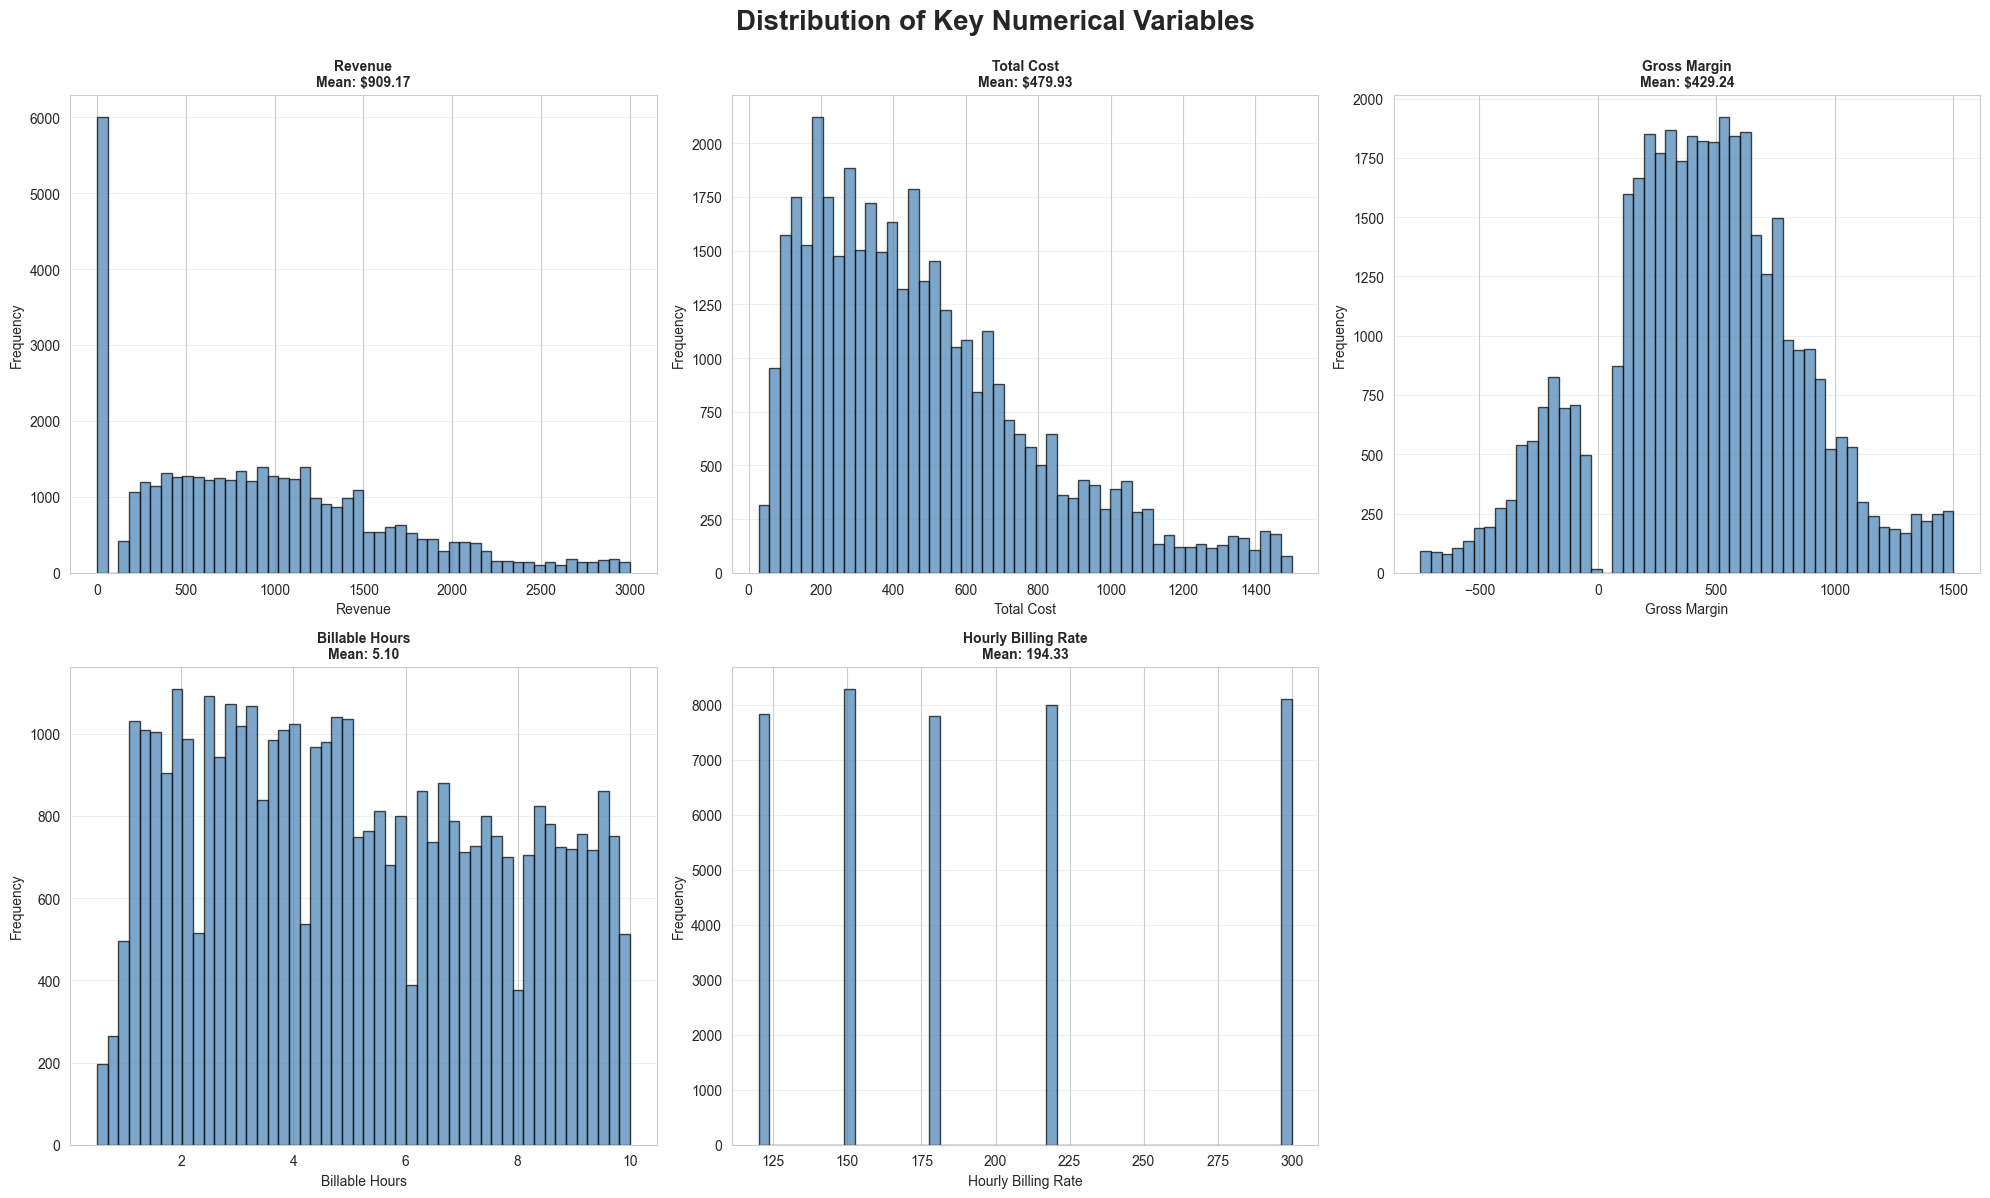

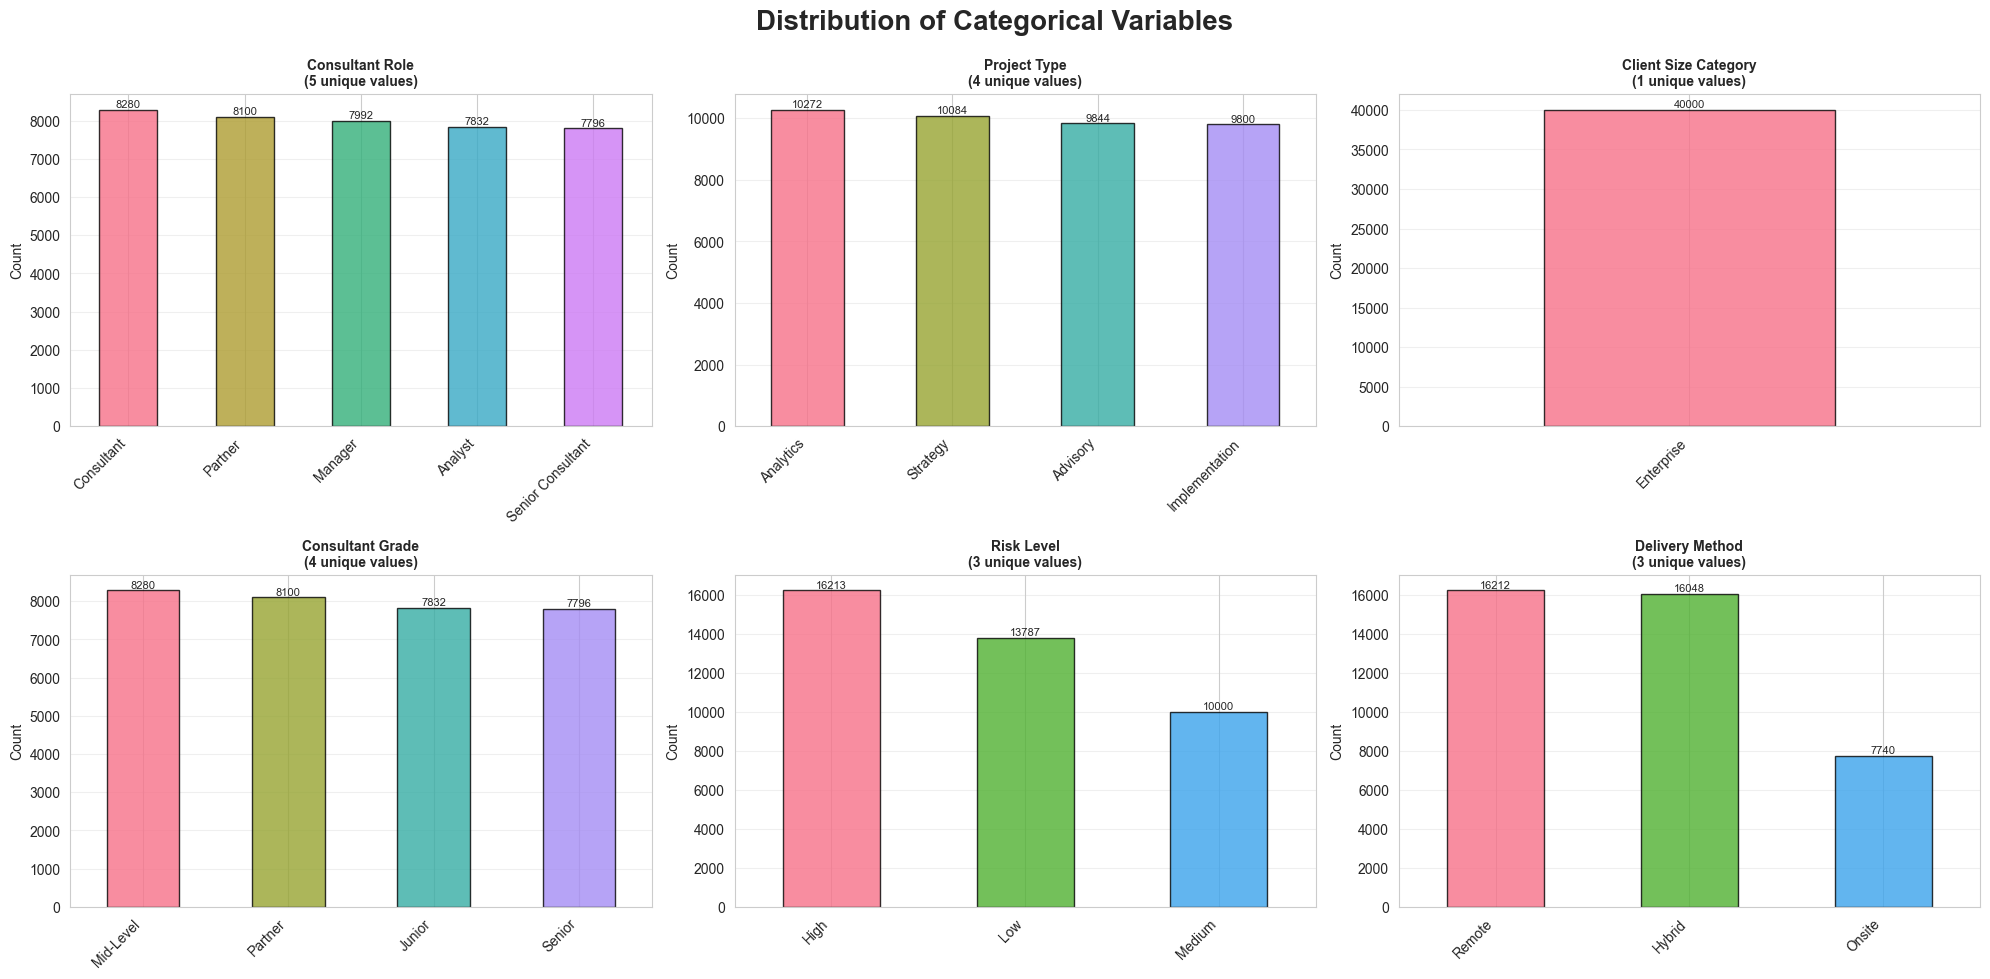

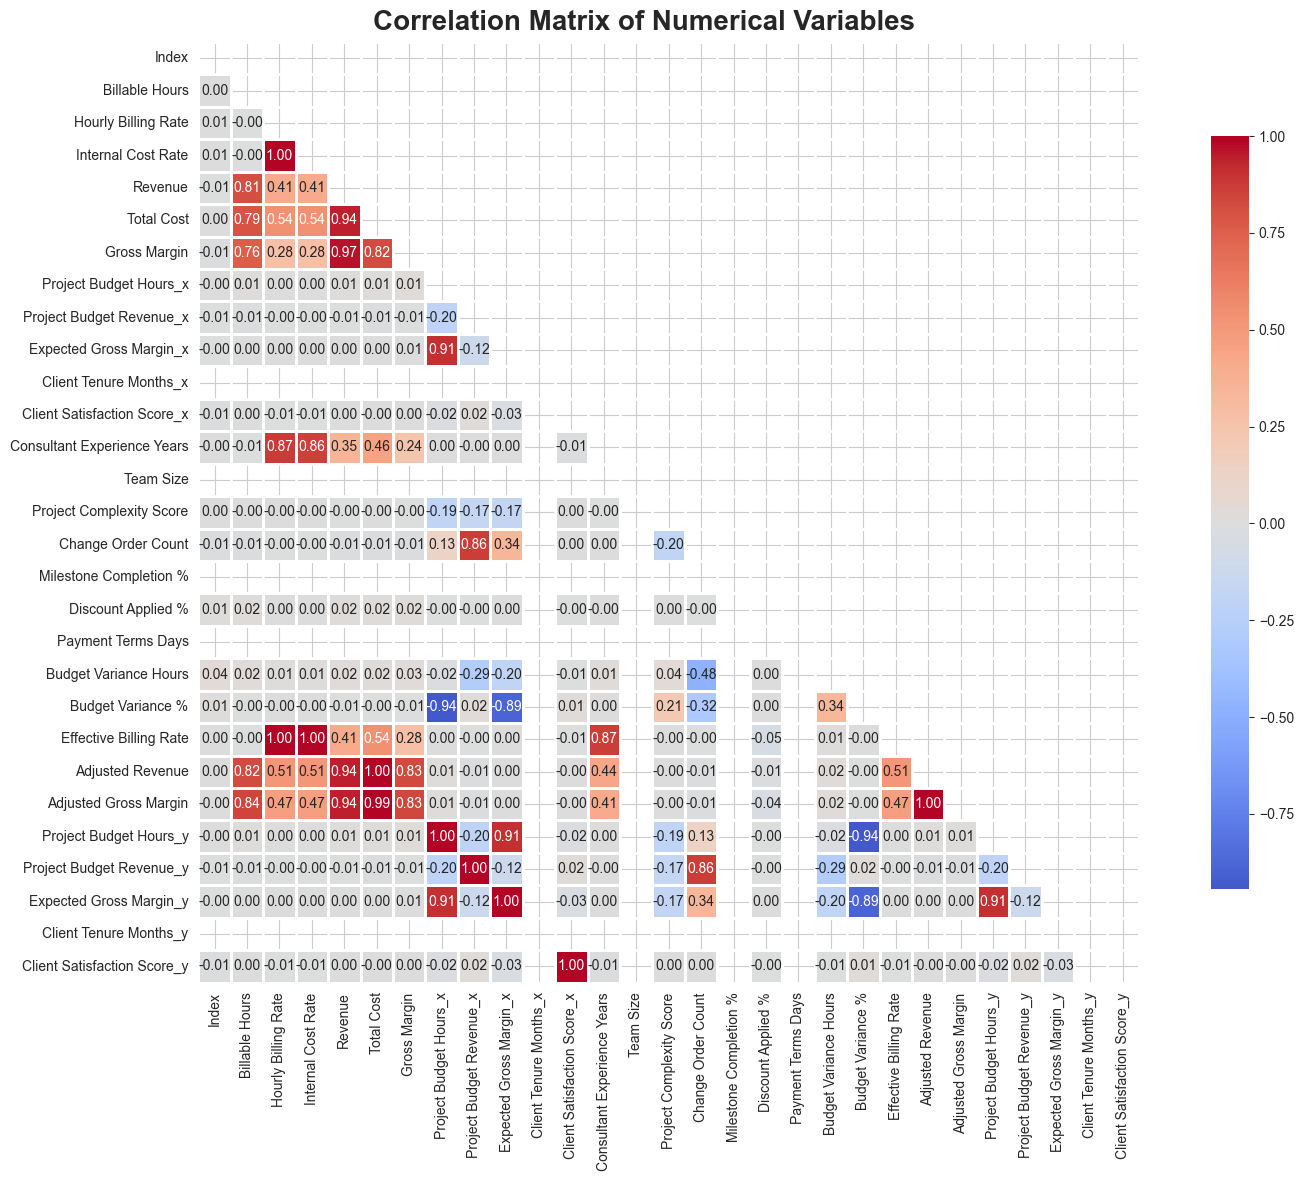

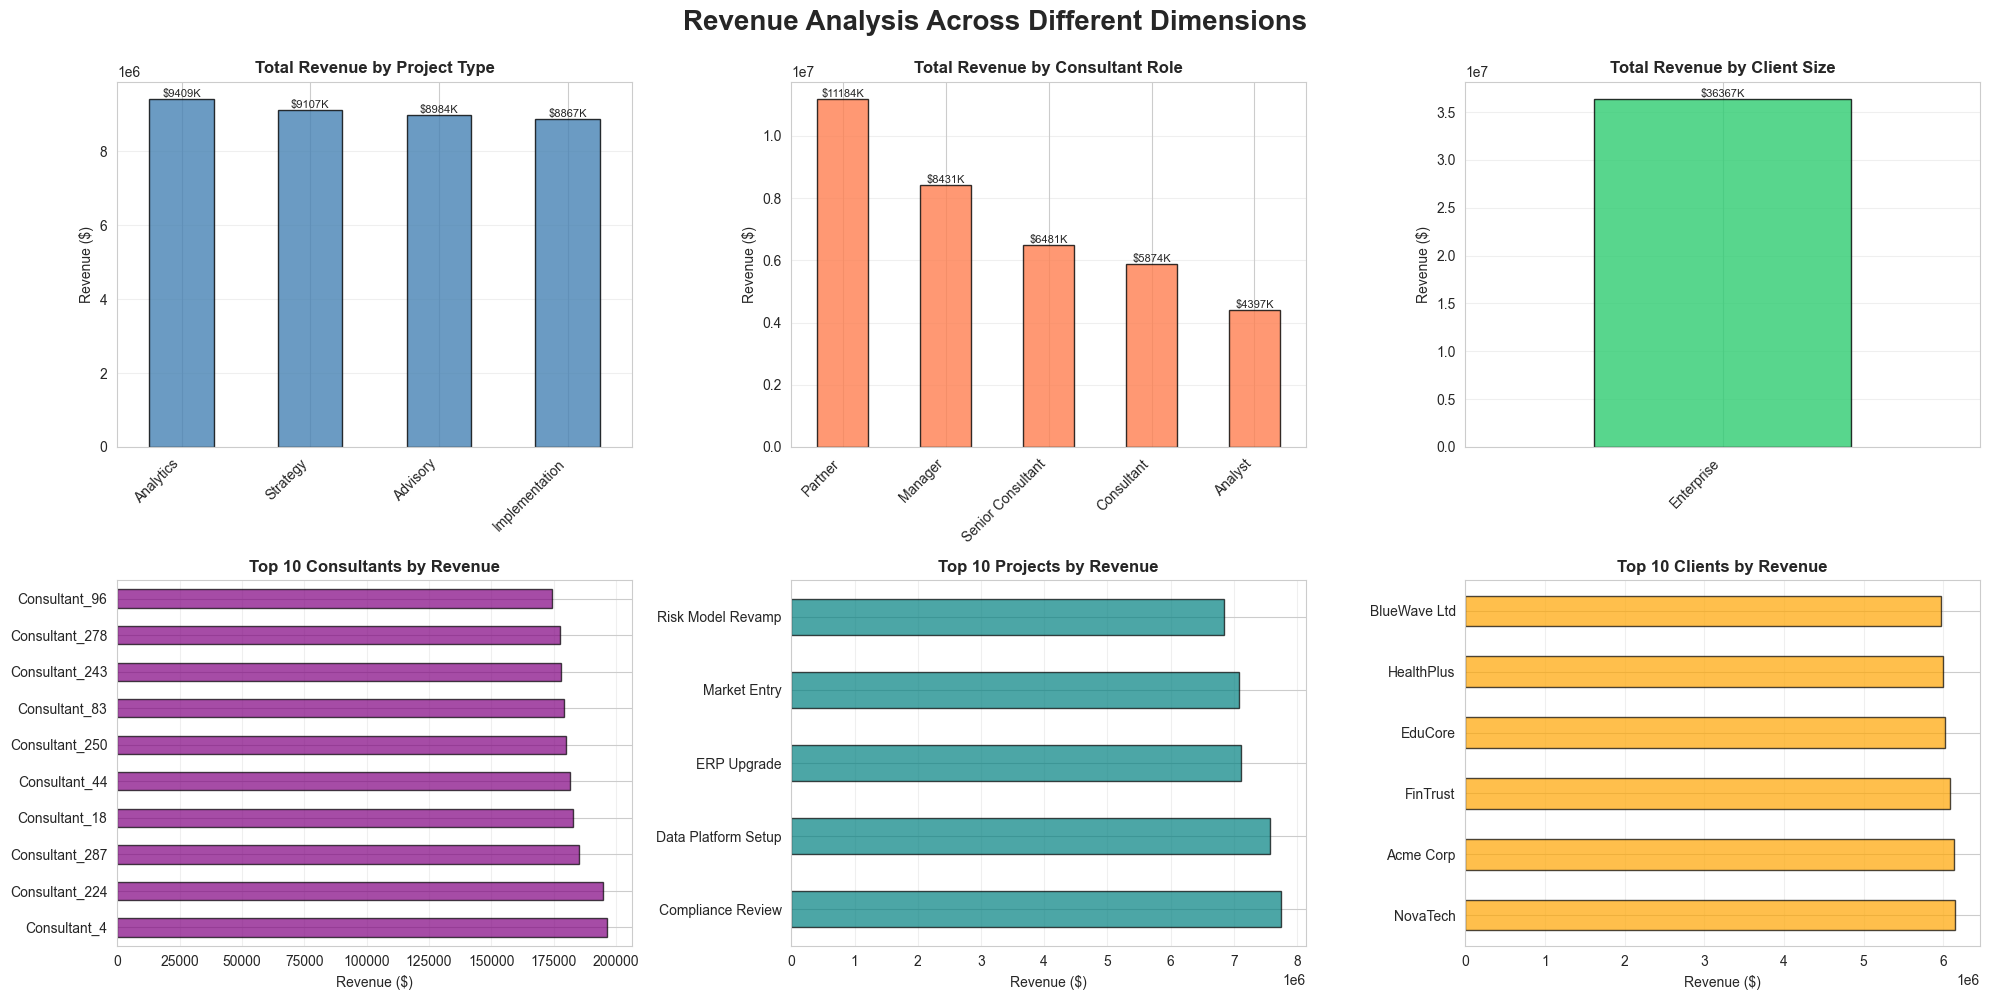

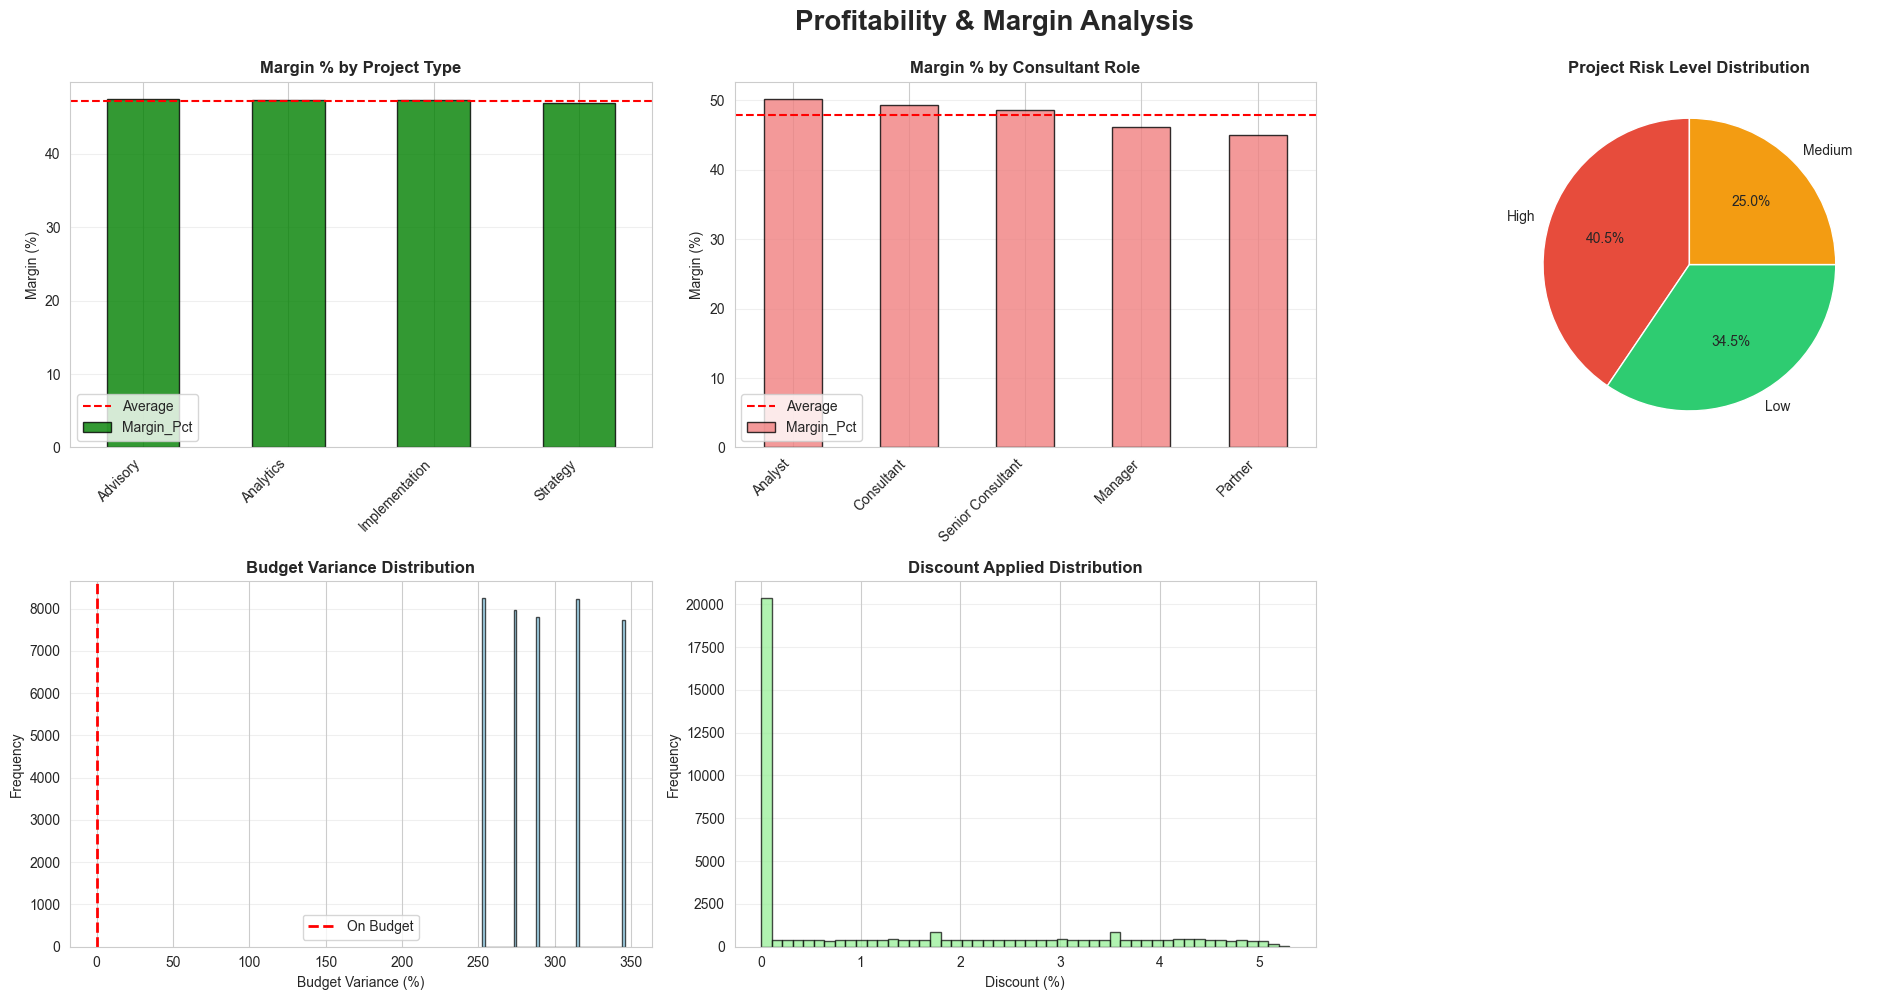

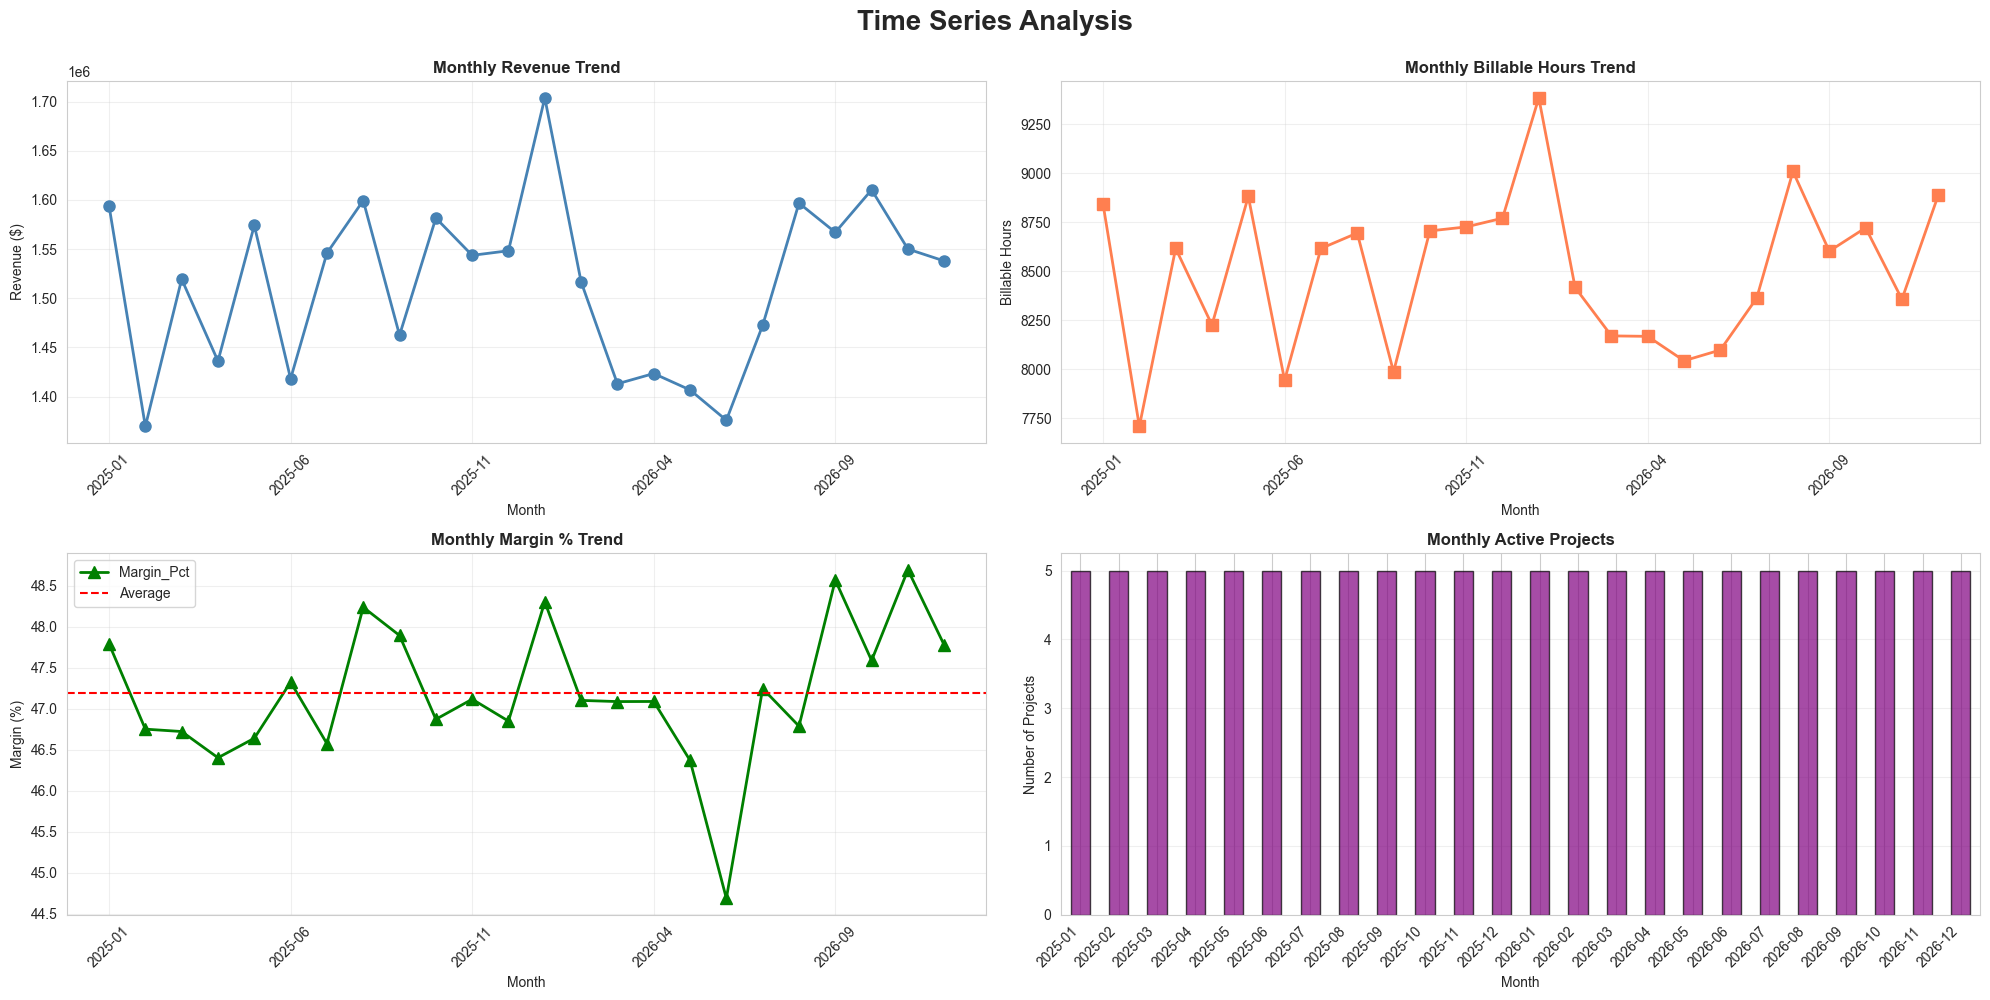


KEY SUMMARY STATISTICS
               Metric          Value
        Total Revenue $36,366,616.00
           Total Cost $19,197,088.00
   Total Gross Margin $17,169,528.00
     Average Margin %         47.21%
 Total Billable Hours     203,932.00
Number of Consultants            299
   Number of Projects              5
    Number of Clients              6

VISUAL ANALYSIS COMPLETE!

✓ All visualizations generated successfully!


In [5]:
# ============================================================================
# COMPLETE VISUAL SUMMARY OF ENHANCED DATASET - FIXED VERSION
# ============================================================================

print("="*80)
print("COMPREHENSIVE VISUAL ANALYSIS OF ENHANCED DATASET")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# ============================================================================
# 1. DATASET OVERVIEW
# ============================================================================

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"\n📊 Dataset Shape: {df_enhanced.shape[0]:,} rows × {df_enhanced.shape[1]} columns")
print(f"\n📅 Date Range: {df_enhanced['Worked Date'].min()} to {df_enhanced['Worked Date'].max()}")

print("\n" + "-"*80)
print("COLUMN SUMMARY")
print("-"*80)

# Display all columns with their data types
column_info = pd.DataFrame({
    'Column Name': df_enhanced.columns,
    'Data Type': df_enhanced.dtypes.values,
    'Non-Null Count': df_enhanced.count().values,
    'Null Count': df_enhanced.isnull().sum().values,
    'Unique Values': [df_enhanced[col].nunique() for col in df_enhanced.columns]
})

print(column_info.to_string(index=False))

print("\n" + "-"*80)
print("SAMPLE DATA (First 10 Rows)")
print("-"*80)
print(df_enhanced.head(10).to_string())

print("\n" + "-"*80)
print("STATISTICAL SUMMARY (Numerical Columns)")
print("-"*80)
print(df_enhanced.describe().round(2).to_string())

# ============================================================================
# 2. COMPREHENSIVE VISUALIZATIONS
# ============================================================================

print("\n\nGenerating comprehensive visualizations...")

# Figure 1: Distribution of Key Numerical Variables
fig1 = plt.figure(figsize=(20, 12))
fig1.suptitle('Distribution of Key Numerical Variables', fontsize=20, fontweight='bold', y=0.995)

numerical_cols = ['Revenue', 'Total Cost', 'Gross Margin', 'Billable Hours',
                  'Hourly Billing Rate']

for idx, col in enumerate(numerical_cols, 1):
    if col in df_enhanced.columns:
        plt.subplot(2, 3, idx)
        df_enhanced[col].hist(bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        if 'Revenue' in col or 'Cost' in col or 'Margin' in col:
            plt.title(f'{col}\nMean: ${df_enhanced[col].mean():,.2f}', fontsize=10, fontweight='bold')
        else:
            plt.title(f'{col}\nMean: {df_enhanced[col].mean():.2f}', fontsize=10, fontweight='bold')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 2: Categorical Variables Distribution
fig2 = plt.figure(figsize=(20, 14))
fig2.suptitle('Distribution of Categorical Variables', fontsize=20, fontweight='bold', y=0.995)

categorical_cols = ['Consultant Role', 'Project Type', 'Client Size Category',
                    'Consultant Grade', 'Risk Level', 'Delivery Method']

plot_idx = 1
for col in categorical_cols:
    if col in df_enhanced.columns:
        plt.subplot(3, 3, plot_idx)
        value_counts = df_enhanced[col].value_counts()
        colors = sns.color_palette("husl", len(value_counts))
        value_counts.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)
        plt.title(f'{col}\n({df_enhanced[col].nunique()} unique values)', fontsize=10, fontweight='bold')
        plt.xlabel('')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for i, v in enumerate(value_counts):
            plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=8)

        plot_idx += 1

plt.tight_layout()
plt.show()

# Figure 3: Correlation Heatmap
fig3 = plt.figure(figsize=(16, 12))
fig3.suptitle('Correlation Matrix of Numerical Variables', fontsize=20, fontweight='bold')

numerical_df = df_enhanced.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.show()

# Figure 4: Revenue Analysis
fig4 = plt.figure(figsize=(20, 10))
fig4.suptitle('Revenue Analysis Across Different Dimensions', fontsize=20, fontweight='bold', y=0.995)

# Revenue by Project Type
plt.subplot(2, 3, 1)
project_revenue = df_enhanced.groupby('Project Type')['Revenue'].sum().sort_values(ascending=False)
project_revenue.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Total Revenue by Project Type', fontweight='bold')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(project_revenue):
    plt.text(i, v, f'${v/1000:.0f}K', ha='center', va='bottom', fontsize=8)

# Revenue by Consultant Role
plt.subplot(2, 3, 2)
role_revenue = df_enhanced.groupby('Consultant Role')['Revenue'].sum().sort_values(ascending=False)
role_revenue.plot(kind='bar', color='coral', edgecolor='black', alpha=0.8)
plt.title('Total Revenue by Consultant Role', fontweight='bold')
plt.xlabel('')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(role_revenue):
    plt.text(i, v, f'${v/1000:.0f}K', ha='center', va='bottom', fontsize=8)

# Revenue by Client Size
if 'Client Size Category' in df_enhanced.columns:
    plt.subplot(2, 3, 3)
    client_revenue = df_enhanced.groupby('Client Size Category')['Revenue'].sum().sort_values(ascending=False)
    colors_client = ['#2ecc71', '#f39c12', '#e74c3c']
    client_revenue.plot(kind='bar', color=colors_client, edgecolor='black', alpha=0.8)
    plt.title('Total Revenue by Client Size', fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Revenue ($)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(client_revenue):
        plt.text(i, v, f'${v/1000:.0f}K', ha='center', va='bottom', fontsize=8)

# Top 10 Consultants by Revenue
plt.subplot(2, 3, 4)
top_consultants = df_enhanced.groupby('Consultant Name')['Revenue'].sum().nlargest(10)
top_consultants.plot(kind='barh', color='purple', edgecolor='black', alpha=0.7)
plt.title('Top 10 Consultants by Revenue', fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

# Top 10 Projects by Revenue
plt.subplot(2, 3, 5)
top_projects = df_enhanced.groupby('Project Name')['Revenue'].sum().nlargest(10)
top_projects.plot(kind='barh', color='teal', edgecolor='black', alpha=0.7)
plt.title('Top 10 Projects by Revenue', fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

# Top 10 Clients by Revenue
plt.subplot(2, 3, 6)
top_clients = df_enhanced.groupby('Client Name')['Revenue'].sum().nlargest(10)
top_clients.plot(kind='barh', color='orange', edgecolor='black', alpha=0.7)
plt.title('Top 10 Clients by Revenue', fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 5: Profitability Analysis
fig5 = plt.figure(figsize=(20, 10))
fig5.suptitle('Profitability & Margin Analysis', fontsize=20, fontweight='bold', y=0.995)

# Margin % by Project Type
plt.subplot(2, 3, 1)
project_margin = df_enhanced.groupby('Project Type').agg({'Revenue': 'sum', 'Gross Margin': 'sum'})
project_margin['Margin_Pct'] = (project_margin['Gross Margin'] / project_margin['Revenue'] * 100)
project_margin['Margin_Pct'].sort_values(ascending=False).plot(kind='bar', color='green', edgecolor='black', alpha=0.8)
plt.title('Margin % by Project Type', fontweight='bold')
plt.xlabel('')
plt.ylabel('Margin (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=project_margin['Margin_Pct'].mean(), color='red', linestyle='--', label='Average')
plt.legend()

# Margin % by Consultant Role
plt.subplot(2, 3, 2)
role_margin = df_enhanced.groupby('Consultant Role').agg({'Revenue': 'sum', 'Gross Margin': 'sum'})
role_margin['Margin_Pct'] = (role_margin['Gross Margin'] / role_margin['Revenue'] * 100)
role_margin['Margin_Pct'].sort_values(ascending=False).plot(kind='bar', color='lightcoral', edgecolor='black', alpha=0.8)
plt.title('Margin % by Consultant Role', fontweight='bold')
plt.xlabel('')
plt.ylabel('Margin (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=role_margin['Margin_Pct'].mean(), color='red', linestyle='--', label='Average')
plt.legend()

# Risk Level Distribution
if 'Risk Level' in df_enhanced.columns:
    plt.subplot(2, 3, 3)
    risk_counts = df_enhanced['Risk Level'].value_counts()
    colors_risk = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
    colors = [colors_risk.get(x, 'gray') for x in risk_counts.index]
    risk_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Project Risk Level Distribution', fontweight='bold')
    plt.ylabel('')

# Budget Variance
if 'Budget Variance %' in df_enhanced.columns:
    plt.subplot(2, 3, 4)
    df_enhanced['Budget Variance %'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('Budget Variance Distribution', fontweight='bold')
    plt.xlabel('Budget Variance (%)')
    plt.ylabel('Frequency')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='On Budget')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()

# Discount Applied Distribution
if 'Discount Applied %' in df_enhanced.columns:
    plt.subplot(2, 3, 5)
    df_enhanced['Discount Applied %'].hist(bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.title('Discount Applied Distribution', fontweight='bold')
    plt.xlabel('Discount (%)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)

# Client Satisfaction Score
if 'Client Satisfaction Score' in df_enhanced.columns:
    plt.subplot(2, 3, 6)
    df_enhanced.groupby('Client Name')['Client Satisfaction Score'].first().hist(bins=30, color='gold', edgecolor='black', alpha=0.7)
    plt.title('Client Satisfaction Score Distribution', fontweight='bold')
    plt.xlabel('Satisfaction Score (0-10)')
    plt.ylabel('Number of Clients')
    plt.grid(axis='y', alpha=0.3)
    avg_satisfaction = df_enhanced.groupby('Client Name')['Client Satisfaction Score'].first().mean()
    plt.axvline(x=avg_satisfaction, color='red', linestyle='--', linewidth=2, label=f'Avg: {avg_satisfaction:.2f}')
    plt.legend()

plt.tight_layout()
plt.show()

# Figure 6: Time Series Analysis
fig6 = plt.figure(figsize=(20, 10))
fig6.suptitle('Time Series Analysis', fontsize=20, fontweight='bold', y=0.995)

df_enhanced['Month'] = pd.to_datetime(df_enhanced['Worked Date']).dt.to_period('M').astype(str)

# Monthly Revenue Trend
plt.subplot(2, 2, 1)
monthly_revenue = df_enhanced.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(kind='line', marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Monthly Revenue Trend', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Monthly Billable Hours
plt.subplot(2, 2, 2)
monthly_hours = df_enhanced.groupby('Month')['Billable Hours'].sum()
monthly_hours.plot(kind='line', marker='s', color='coral', linewidth=2, markersize=8)
plt.title('Monthly Billable Hours Trend', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Billable Hours')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Monthly Margin %
plt.subplot(2, 2, 3)
monthly_metrics = df_enhanced.groupby('Month').agg({'Revenue': 'sum', 'Gross Margin': 'sum'})
monthly_metrics['Margin_Pct'] = (monthly_metrics['Gross Margin'] / monthly_metrics['Revenue'] * 100)
monthly_metrics['Margin_Pct'].plot(kind='line', marker='^', color='green', linewidth=2, markersize=8)
plt.title('Monthly Margin % Trend', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Margin (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=monthly_metrics['Margin_Pct'].mean(), color='red', linestyle='--', label='Average')
plt.legend()

# Monthly Project Count
plt.subplot(2, 2, 4)
monthly_projects = df_enhanced.groupby('Month')['Project Name'].nunique()
monthly_projects.plot(kind='bar', color='purple', edgecolor='black', alpha=0.7)
plt.title('Monthly Active Projects', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Projects')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "="*80)
print("KEY SUMMARY STATISTICS")
print("="*80)

summary_stats = {
    'Metric': [
        'Total Revenue',
        'Total Cost',
        'Total Gross Margin',
        'Average Margin %',
        'Total Billable Hours',
        'Number of Consultants',
        'Number of Projects',
        'Number of Clients'
    ],
    'Value': [
        f"${df_enhanced['Revenue'].sum():,.2f}",
        f"${df_enhanced['Total Cost'].sum():,.2f}",
        f"${df_enhanced['Gross Margin'].sum():,.2f}",
        f"{(df_enhanced['Gross Margin'].sum() / df_enhanced['Revenue'].sum() * 100):.2f}%",
        f"{df_enhanced['Billable Hours'].sum():,.2f}",
        df_enhanced['Consultant Name'].nunique(),
        df_enhanced['Project Name'].nunique(),
        df_enhanced['Client Name'].nunique()
    ]
}

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("VISUAL ANALYSIS COMPLETE!")
print("="*80)
print("\n✓ All visualizations generated successfully!")

In [6]:
# ============================================================================
# DASHBOARD - RICH VERSION FOR STEEVES & ASSOCIATES (FIXED)
# ============================================================================

print("="*80)
print("CREATING ENHANCED INTERACTIVE DASHBOARD")
print("="*80)

import os
os.environ["DASH_JUPYTER_MODE"] = "external"

from dash import Dash, dcc, html, Input, Output, callback
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# Initialize app
class NoopDash:
    def __init__(self):
        self.layout = None

    def run(self, *args, **kwargs):
        print("Dash server launch skipped.")

run_dash_app = os.environ.get("RUN_DASH_APP", "0") == "1"
app = Dash(__name__) if run_dash_app else NoopDash()

# =====================================================================
# ENHANCED CHART FUNCTIONS
# =====================================================================

def create_kpi_cards(df):
    """Create KPI summary cards"""
    total_revenue = df['Revenue'].sum()
    total_margin = df['Gross Margin'].sum()
    margin_pct = (total_margin / total_revenue * 100) if total_revenue > 0 else 0
    total_hours = df['Billable Hours'].sum()
    num_consultants = df['Consultant Name'].nunique()
    num_projects = df['Project Name'].nunique()
    num_clients = df['Client Name'].nunique()
    avg_satisfaction = df.groupby('Client Name')['Client Satisfaction Score_y'].first().mean()

    return html.Div([
        html.Div([
            # Revenue Card
            html.Div([
                html.H4("Total Revenue", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"${total_revenue:,.0f}", style={'color': '#2c3e50', 'margin': '10px 0'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

            # Margin Card
            html.Div([
                html.H4("Gross Margin", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"${total_margin:,.0f}", style={'color': '#27ae60', 'margin': '10px 0'}),
                html.P(f"{margin_pct:.1f}%", style={'color': '#27ae60', 'fontSize': '16px'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

            # Hours Card
            html.Div([
                html.H4("Billable Hours", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"{total_hours:,.0f}", style={'color': '#3498db', 'margin': '10px 0'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

            # Consultants Card
            html.Div([
                html.H4("Consultants", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"{num_consultants}", style={'color': '#9b59b6', 'margin': '10px 0'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

            # Projects Card
            html.Div([
                html.H4("Active Projects", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"{num_projects}", style={'color': '#e74c3c', 'margin': '10px 0'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

            # Clients Card
            html.Div([
                html.H4("Total Clients", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"{num_clients}", style={'color': '#f39c12', 'margin': '10px 0'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

            # Satisfaction Card
            html.Div([
                html.H4("Avg Satisfaction", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                html.H2(f"{avg_satisfaction:.1f}/10", style={'color': '#16a085', 'margin': '10px 0'}),
            ], style={'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px',
                     'boxShadow': '0 2px 4px rgba(0,0,0,0.1)', 'textAlign': 'center'}),

        ], style={'display': 'grid', 'gridTemplateColumns': 'repeat(auto-fit, minmax(150px, 1fr))',
                 'gap': '20px', 'marginBottom': '30px'})
    ])

def create_revenue_trend(df):
    """Monthly revenue trend"""
    df_copy = df.copy()
    df_copy['Month'] = pd.to_datetime(df_copy['Worked Date']).dt.to_period('M').astype(str)
    monthly = df_copy.groupby('Month').agg({
        'Revenue': 'sum',
        'Gross Margin': 'sum',
        'Billable Hours': 'sum'
    }).reset_index()

    fig = make_subplots(specs=[[{"secondary_y": True}]])

    fig.add_trace(
        go.Scatter(x=monthly['Month'], y=monthly['Revenue'],
                  name='Revenue', line=dict(color='#3498db', width=3)),
        secondary_y=False
    )

    fig.add_trace(
        go.Scatter(x=monthly['Month'], y=monthly['Gross Margin'],
                  name='Gross Margin', line=dict(color='#27ae60', width=3)),
        secondary_y=False
    )

    fig.add_trace(
        go.Bar(x=monthly['Month'], y=monthly['Billable Hours'],
               name='Billable Hours', marker_color='rgba(52, 152, 219, 0.3)'),
        secondary_y=True
    )

    fig.update_layout(
        title='Revenue & Margin Trend Over Time',
        height=450,
        hovermode='x unified'
    )
    fig.update_xaxes(title_text="Month")
    # Corrected Syntax: ensure the string is properly closed and not prematurely escaped
    fig.update_yaxes(title_text="Amount ($)", secondary_y=False)
    fig.update_yaxes(title_text="Hours", secondary_y=True)

    return fig

def create_consultant_performance_matrix(df):
    """Consultant performance heatmap"""
    perf = df.groupby(['Consultant Name', 'Consultant Role']).agg({
        'Revenue': 'sum',
        'Billable Hours': 'sum',
        'Gross Margin': 'sum'
    }).reset_index()

    perf['Margin_Pct'] = (perf['Gross Margin'] / perf['Revenue'] * 100).round(1)
    perf['Hourly Rate'] = (perf['Revenue'] / perf['Billable Hours']).round(2)

    top_15 = perf.nlargest(15, 'Revenue')

    fig = px.scatter(top_15,
                     x='Billable Hours',
                     y='Margin_Pct',
                     size='Revenue',
                     color='Consultant Role',
                     hover_name='Consultant Name',
                     hover_data={'Billable Hours': ':.0f',
                                'Margin_Pct': ':.1f',
                                'Revenue': ':$,.0f'},
                     title='Consultant Performance Matrix (Top 15 by Revenue)',
                     labels={'Billable Hours': 'Total Billable Hours',
                            'Margin_Pct': 'Profit Margin (%)'},
                     color_discrete_sequence=px.colors.qualitative.Set2)

    fig.update_layout(height=500)
    return fig

def create_project_profitability_heatmap(df):
    """Project profitability by type and complexity"""
    if 'Project Complexity Score' not in df.columns:
        df = df.copy()
        df['Project Complexity Score'] = 3  # Default value

    proj = df.groupby(['Project Type', 'Project Complexity Score']).agg({
        'Revenue': 'sum',
        'Gross Margin': 'sum'
    }).reset_index()

    proj['Margin_Pct'] = (proj['Gross Margin'] / proj['Revenue'] * 100).round(1)

    pivot = proj.pivot_table(
        values='Margin_Pct',
        index='Project Type',
        columns='Project Complexity Score',
        aggfunc='mean'
    ).fillna(0)

    fig = px.imshow(pivot,
                    labels=dict(x="Complexity Score", y="Project Type", color="Margin %"),
                    title='Profitability Heatmap: Project Type vs Complexity',
                    color_continuous_scale='RdYlGn',
                    aspect='auto')

    fig.update_layout(height=400)
    return fig

def create_client_segmentation(df):
    """Client segmentation analysis"""
    df_copy = df.copy()
    if 'Client Size Category' not in df_copy.columns:
        client_revenue = df_copy.groupby('Client Name')['Revenue'].sum().reset_index()
        client_revenue['Client Size Category'] = pd.cut(
            client_revenue['Revenue'],
            bins=[0, 50000, 200000, float('inf')],
            labels=['Small Business', 'Mid-Market', 'Enterprise']
        )
        df_copy = df_copy.merge(client_revenue[['Client Name', 'Client Size Category']],
                     on='Client Name', how='left', suffixes=('', '_new'))
        if 'Client Size Category_new' in df_copy.columns:
            df_copy['Client Size Category'] = df_copy['Client Size Category_new']

    seg = df_copy.groupby('Client Size Category').agg({
        'Revenue': 'sum',
        'Gross Margin': 'sum',
        'Client Name': 'nunique'
    }).reset_index()

    seg.columns = ['Segment', 'Revenue', 'Gross Margin', 'Client Count']
    seg['Avg Revenue per Client'] = seg['Revenue'] / seg['Client Count']
    seg['Margin_Pct'] = (seg['Gross Margin'] / seg['Revenue'] * 100).round(1)

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Revenue by Client Segment', 'Client Distribution'),
        specs=[[{"type": "bar"}, {"type": "pie"}]]
    )

    fig.add_trace(
        go.Bar(x=seg['Segment'], y=seg['Revenue'],
               marker_color=['#3498db', '#9b59b6', '#e74c3c'],
               text=seg['Revenue'].apply(lambda x: f'${x/1000:.0f}K'),
               textposition='outside'),
        row=1, col=1
    )

    fig.add_trace(
        go.Pie(labels=seg['Segment'], values=seg['Client Count'],
               marker_colors=['#3498db', '#9b59b6', '#e74c3c']),
        row=1, col=2
    )

    fig.update_layout(height=400, showlegend=False, title_text='Client Segmentation Analysis')
    return fig

def create_utilization_by_location(df):
    """Consultant utilization by location"""
    df_copy = df.copy()
    if 'Consultant Location' not in df_copy.columns:
        locations = ['Vancouver', 'Toronto', 'Calgary', 'Montreal', 'Remote']
        consultant_locations = pd.DataFrame({
            'Consultant Name': df_copy['Consultant Name'].unique(),
            'Consultant Location': np.random.choice(locations, len(df_copy['Consultant Name'].unique()),
                                                   p=[0.3, 0.25, 0.15, 0.15, 0.15])
        })
        df_copy = df_copy.merge(consultant_locations, on='Consultant Name', how='left')

    loc = df_copy.groupby('Consultant Location').agg({
        'Billable Hours': 'sum',
        'Revenue': 'sum',
        'Consultant Name': 'nunique'
    }).reset_index()

    loc['Avg Hours per Consultant'] = (loc['Billable Hours'] / loc['Consultant Name']).round(1)
    loc['Avg Revenue per Consultant'] = (loc['Revenue'] / loc['Consultant Name']).round(0)

    fig = px.bar(loc, x='Consultant Location', y='Avg Hours per Consultant',
                 color='Avg Revenue per Consultant',
                 title='Average Utilization by Location',
                 labels={'Avg Hours per Consultant': 'Avg Billable Hours',
                        'Avg Revenue per Consultant': 'Avg Revenue ($)'},
                 color_continuous_scale='Viridis',
                 text='Avg Hours per Consultant')

    fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
    fig.update_layout(height=450)
    return fig

def create_role_profitability(df):
    """Profitability analysis by consultant role"""
    role = df.groupby('Consultant Role').agg({
        'Revenue': 'sum',
        'Gross Margin': 'sum',
        'Billable Hours': 'sum',
        'Consultant Name': 'nunique'
    }).reset_index()

    role['Margin_Pct'] = (role['Gross Margin'] / role['Revenue'] * 100).round(1)
    role['Avg Hourly Rate'] = (role['Revenue'] / role['Billable Hours']).round(2)

    fig = go.Figure()

    fig.add_trace(go.Bar(
        name='Revenue',
        x=role['Consultant Role'],
        y=role['Revenue'],
        marker_color='#3498db',
        yaxis='y',
        offsetgroup=0
    ))

    fig.add_trace(go.Scatter(
        name='Margin %',
        x=role['Consultant Role'],
        y=role['Margin_Pct'],
        marker_color='#e74c3c',
        yaxis='y2',
        mode='lines+markers',
        line=dict(width=3)
    ))

    fig.update_layout(
        title='Revenue & Profitability by Consultant Role',
        xaxis=dict(title='Role', tickangle=-45),
        yaxis=dict(title='Revenue ($)', side='left'),
        yaxis2=dict(title='Margin (%)', overlaying='y', side='right'),
        height=450,
        hovermode='x unified'
    )

    return fig

def create_project_timeline(df):
    """Project timeline and status"""
    proj = df.groupby('Project Name').agg({
        'Worked Date': ['min', 'max'],
        'Revenue': 'sum',
        'Gross Margin': 'sum',
        'Project Type': 'first'
    }).reset_index()

    proj.columns = ['Project', 'Start', 'End', 'Revenue', 'Margin', 'Type']
    proj['Duration'] = (proj['End'] - proj['Start']).dt.days
    proj = proj.nlargest(15, 'Revenue')

    fig = px.timeline(proj, x_start='Start', x_end='End', y='Project',
                      color='Type',
                      title='Top 15 Projects Timeline',
                      labels={'Project': 'Project Name'},
                      color_discrete_sequence=px.colors.qualitative.Set2)

    fig.update_yaxes(categoryorder='total ascending')
    fig.update_layout(height=500)
    return fig

def create_top_consultants_chart(df):
    m = df.groupby('Consultant Name')[['Revenue', 'Billable Hours']].sum().reset_index()
    m = m.nlargest(10, 'Revenue')
    fig = px.bar(m, x='Revenue', y='Consultant Name', orientation='h',
                 title='Top 10 Consultants by Revenue',
                 color='Revenue', color_continuous_scale='Blues')
    fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
    return fig

def create_utilization_by_role(df):
    m = df.groupby('Consultant Role')['Billable Hours'].sum().reset_index()
    fig = px.bar(m, x='Consultant Role', y='Billable Hours',
                 title='Total Billable Hours by Role',
                 color='Billable Hours', color_continuous_scale='Viridis')
    fig.update_layout(height=500, xaxis_tickangle=-45)
    return fig

def create_top_projects_chart(df):
    m = df.groupby('Project Name')[['Gross Margin', 'Revenue']].sum().reset_index()
    m = m[m['Revenue'] > 0]
    m['Margin_Pct'] = (m['Gross Margin'] / m['Revenue']) * 100
    m = m.nlargest(10, 'Gross Margin')
    fig = px.bar(m, x='Gross Margin', y='Project Name', orientation='h',
                 title='Top 10 Projects by Gross Margin',
                 color='Margin_Pct', color_continuous_scale='RdYlGn')
    fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
    return fig

def create_project_type_chart(df):
    m = df.groupby('Project Type')[['Revenue', 'Gross Margin']].sum().reset_index()
    fig = go.Figure([
        go.Bar(name='Revenue', x=m['Project Type'], y=m['Revenue'], marker_color='#3498db'),
        go.Bar(name='Gross Margin', x=m['Project Type'], y=m['Gross Margin'], marker_color='#2ecc71')
    ])
    fig.update_layout(title='Revenue vs Gross Margin by Project Type',
                      barmode='group', height=500, xaxis_tickangle=-45)
    return fig

def create_top_clients_chart(df):
    m = df.groupby('Client Name')['Revenue'].sum().reset_index().nlargest(10, 'Revenue')
    fig = px.bar(m, x='Revenue', y='Client Name', orientation='h',
                 title='Top 10 Clients by Revenue',
                 color='Revenue', color_continuous_scale='Oranges')
    fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
    return fig

def create_satisfaction_scatter(df):
    m = df.groupby('Client Name').agg({
        'Client Satisfaction Score_y': 'first',
        'Revenue': 'sum',
        'Gross Margin': 'sum'
    }).reset_index()
    m = m[m['Revenue'] > 0]
    m['Margin_Pct'] = (m['Gross Margin'] / m['Revenue']) * 100
    fig = px.scatter(m, x='Client Satisfaction Score_y', y='Margin_Pct',
                     size='Revenue', hover_name='Client Name',
                     title='Client Satisfaction vs Profitability',
                     color='Margin_Pct', color_continuous_scale='RdYlGn',
                     size_max=60)
    fig.update_layout(height=500)
    return fig


app.layout = html.Div([
    # Header
    html.Div([
        html.H1("🏢 Steeves & Associates",
                style={'margin': '0', 'color': 'white', 'fontSize': '36px'}),
        html.P("Time Entry Analytics Dashboard",
               style={'margin': '5px 0 0 0', 'color': '#ecf0f1', 'fontSize': '18px'}),
    ], style={'backgroundColor': '#2c3e50', 'padding': '30px', 'textAlign': 'center'}),

    # KPI Cards
    html.Div([
        create_kpi_cards(df_enhanced)
    ], style={'padding': '20px', 'backgroundColor': '#ecf0f1'}),

    # Main Content
    html.Div([
        dcc.Tabs([
            # TAB 1: OVERVIEW
            dcc.Tab(label='📊 Overview', children=[
                html.Div([
                    dcc.Graph(figure=create_revenue_trend(df_enhanced)),
                    html.Div([
                        html.Div([dcc.Graph(figure=create_client_segmentation(df_enhanced))],
                                style={'width': '50%'}),
                        html.Div([dcc.Graph(figure=create_project_profitability_heatmap(df_enhanced))],
                                style={'width': '50%'}),
                    ], style={'display': 'flex', 'gap': '20px'}),
                ], style={'padding': '20px'})
            ]),

            # TAB 2: CONSULTANT ANALYSIS
            dcc.Tab(label='👥 Consultant Performance', children=[
                html.Div([
                    dcc.Graph(figure=create_consultant_performance_matrix(df_enhanced)),
                    html.Div([
                        html.Div([dcc.Graph(figure=create_role_profitability(df_enhanced))],
                                style={'width': '50%'}),
                        html.Div([dcc.Graph(figure=create_utilization_by_location(df_enhanced))],
                                style={'width': '50%'}),
                    ], style={'display': 'flex', 'gap': '20px'}),
                ], style={'padding': '20px'})
            ]),

            # TAB 3: PROJECT ANALYSIS
            dcc.Tab(label='💼 Project Analysis', children=[
                html.Div([
                    dcc.Graph(figure=create_project_timeline(df_enhanced)),
                    html.Div([
                        html.Div([dcc.Graph(figure=create_top_projects_chart(df_enhanced))],
                                style={'width': '50%'}),
                        html.Div([dcc.Graph(figure=create_project_type_chart(df_enhanced))],
                                style={'width': '50%'}),
                    ], style={'display': 'flex', 'gap': '20px'}),
                ], style={'padding': '20px'})
            ]),

            # TAB 4: CLIENT ANALYSIS
            dcc.Tab(label='🤝 Client Insights', children=[
                html.Div([
                    dcc.Graph(figure=create_satisfaction_scatter(df_enhanced)),
                    html.Div([
                        html.Div([dcc.Graph(figure=create_top_clients_chart(df_enhanced))],
                                style={'width': '50%'}),
                        html.Div([dcc.Graph(figure=create_client_segmentation(df_enhanced))],
                                style={'width': '50%'}),
                    ], style={'display': 'flex', 'gap': '20px'}),
                ], style={'padding': '20px'})
            ]),
        ])
    ], style={'backgroundColor': 'white', 'minHeight': '100vh'}),

], style={'fontFamily': 'Arial, sans-serif', 'backgroundColor': '#ecf0f1'})

print("✓ Enhanced Dashboard created successfully!")
print("\nLaunching dashboard...")

import os

# Run the app (works both locally and in Colab)
try:
    from google.colab import output  # type: ignore
    output.serve_kernel_port_as_iframe(8050, height=900)
except ImportError:
    print("Running outside Colab. Open http://127.0.0.1:8050 in your browser.")

# Avoid blocking automated notebook execution.
if run_dash_app:
    app.run(debug=False, port=8050, host='0.0.0.0')
else:
    print("Skipping Dash server start during notebook execution. Set RUN_DASH_APP=1 to launch.")

CREATING ENHANCED INTERACTIVE DASHBOARD


✓ Enhanced Dashboard created successfully!

Launching dashboard...
Running outside Colab. Open http://127.0.0.1:8050 in your browser.
Skipping Dash server start during notebook execution. Set RUN_DASH_APP=1 to launch.
